## Implementing Simple Chatbot using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm.invoke("Hello I am shivansh")

AIMessage(content="Hello Shivansh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.053968627, 'completion_tokens_details': None, 'prompt_time': 0.00373522, 'prompt_tokens_details': None, 'queue_time': 0.164917819, 'total_time': 0.057703847}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1870-38aa-7103-a521-eda9b3533877-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70})

## Creating Nodes


In [5]:
def superbot(state:State):
    return{"messages":[llm.invoke(state['messages'])]}

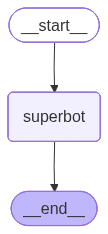

In [7]:
graph = StateGraph(State)

##node
graph.add_node("superbot",superbot)
## Edges
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile()

##Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
## Invocation
graph_builder.invoke({"messages":"Hi, My name is Shivansh and I Like cricket"})

{'messages': [HumanMessage(content='Hi, My name is Shivansh and I Like cricket', additional_kwargs={}, response_metadata={}, id='24b8c83c-7205-416c-9fa1-645600edf9c2'),
  AIMessage(content='Nice to meet you, Shivansh! Cricket is an amazing sport, and there are so many exciting matches and players to follow. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 47, 'total_tokens': 109, 'completion_time': 0.209199735, 'completion_tokens_details': None, 'prompt_time': 0.006638394, 'prompt_tokens_details': None, 'queue_time': 0.160837836, 'total_time': 0.215838129}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1873-ccf8-7693-aaf4-15f654bf4caa-0', tool_calls=[], invalid_too

##Streaming the Responses

In [13]:
for event in graph_builder.stream({"messages":"Hello I'm shivansh"},stream_mode="values"):
    print(event)


{'messages': [HumanMessage(content="Hello I'm shivansh", additional_kwargs={}, response_metadata={}, id='d8a3f1e0-bd54-4725-b92d-8ec2cac5f629')]}
{'messages': [HumanMessage(content="Hello I'm shivansh", additional_kwargs={}, response_metadata={}, id='d8a3f1e0-bd54-4725-b92d-8ec2cac5f629'), AIMessage(content="Hello Shivansh! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.046117375, 'completion_tokens_details': None, 'prompt_time': 0.001200051, 'prompt_tokens_details': None, 'queue_time': 0.164856188, 'total_time': 0.047317426}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1876-638a-7862-8808-e14baff8a275-0', tool_calls=[], invalid_tool_calls=[], usage_met